# Studi Kasus 2: Profil Kebiasaan Hidup Mahasiswa (Unsupervised Learning)

Tugas akhir mata kuliah Fundamental Sains Data (TriVerse). Notebook ini mencakup bagian **EDA dan preprocessing** (PIC: Hidayat Nur Hijrah). Bagian training & evaluasi K-Means (Elbow Method, Silhouette Score) dikerjakan terpisah oleh Muhamad Rafi Raditya, melanjutkan dari feature matrix yang disiapkan di akhir notebook ini.

Dataset: Kaggle `jayaantanaath/student-habits-vs-academic-performance`. Tujuan: mengelompokkan mahasiswa berdasarkan kebiasaan hidup (belajar, tidur, penggunaan media sosial, dll), **bukan** berdasarkan hasil akademik, supaya insight yang didapat murni tentang pola kebiasaan.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [11]:
import os
data_path = os.path.join("..", "data", "student_habits_performance.csv")
df = pd.read_csv(data_path)
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 1. Pemahaman Dataset

In [12]:
print("Jumlah baris, kolom:", df.shape)
df.info()

Jumlah baris, kolom: (1000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality            

Dataset berisi 1.000 baris dan 16 kolom: `student_id` (identifier), beberapa kolom demografis (`age`, `gender`, `parental_education_level`), kolom kebiasaan hidup (`study_hours_per_day`, `social_media_hours`, `netflix_hours`, `attendance_percentage`, `sleep_hours`, `diet_quality`, `exercise_frequency`, `internet_quality`, `part_time_job`, `extracurricular_participation`, `mental_health_rating`), dan `exam_score` sebagai hasil akademik. Berbeda dengan dataset Studi Kasus 1, di sini ada campuran tipe numerik dan kategorikal (`gender`, `part_time_job`, `diet_quality`, `parental_education_level`, `internet_quality`, `extracurricular_participation`).

## 2. Pemeriksaan Kualitas Data (Missing Value & Duplikat)

In [13]:
print("Missing value per kolom:")
print(df.isnull().sum())
print()
print("Total baris duplikat:", df.duplicated().sum())

Missing value per kolom:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Total baris duplikat: 0


Ditemukan **91 missing value (9,1%)** pada kolom `parental_education_level`, dan tidak ada baris duplikat. Kolom `parental_education_level` bersifat demografis (latar belakang keluarga), bukan kebiasaan hidup mahasiswa itu sendiri, sehingga **tidak digunakan sebagai fitur clustering** (lihat justifikasi pemilihan fitur di bagian 6). Karena itu, missing value ini tidak perlu diimputasi untuk kebutuhan clustering; kolom ini tetap dipertahankan di dataframe hanya sebagai konteks deskriptif.

## 3. Statistik Deskriptif

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


Rentang nilai antar fitur numerik bervariasi cukup jauh (misalnya `attendance_percentage` berskala 0-100, sementara `sleep_hours` berskala sekitar 0-10), sehingga scaling tetap wajib dilakukan sebelum clustering karena K-Means sensitif terhadap skala fitur.

## 4. Visualisasi dan Eksplorasi Data

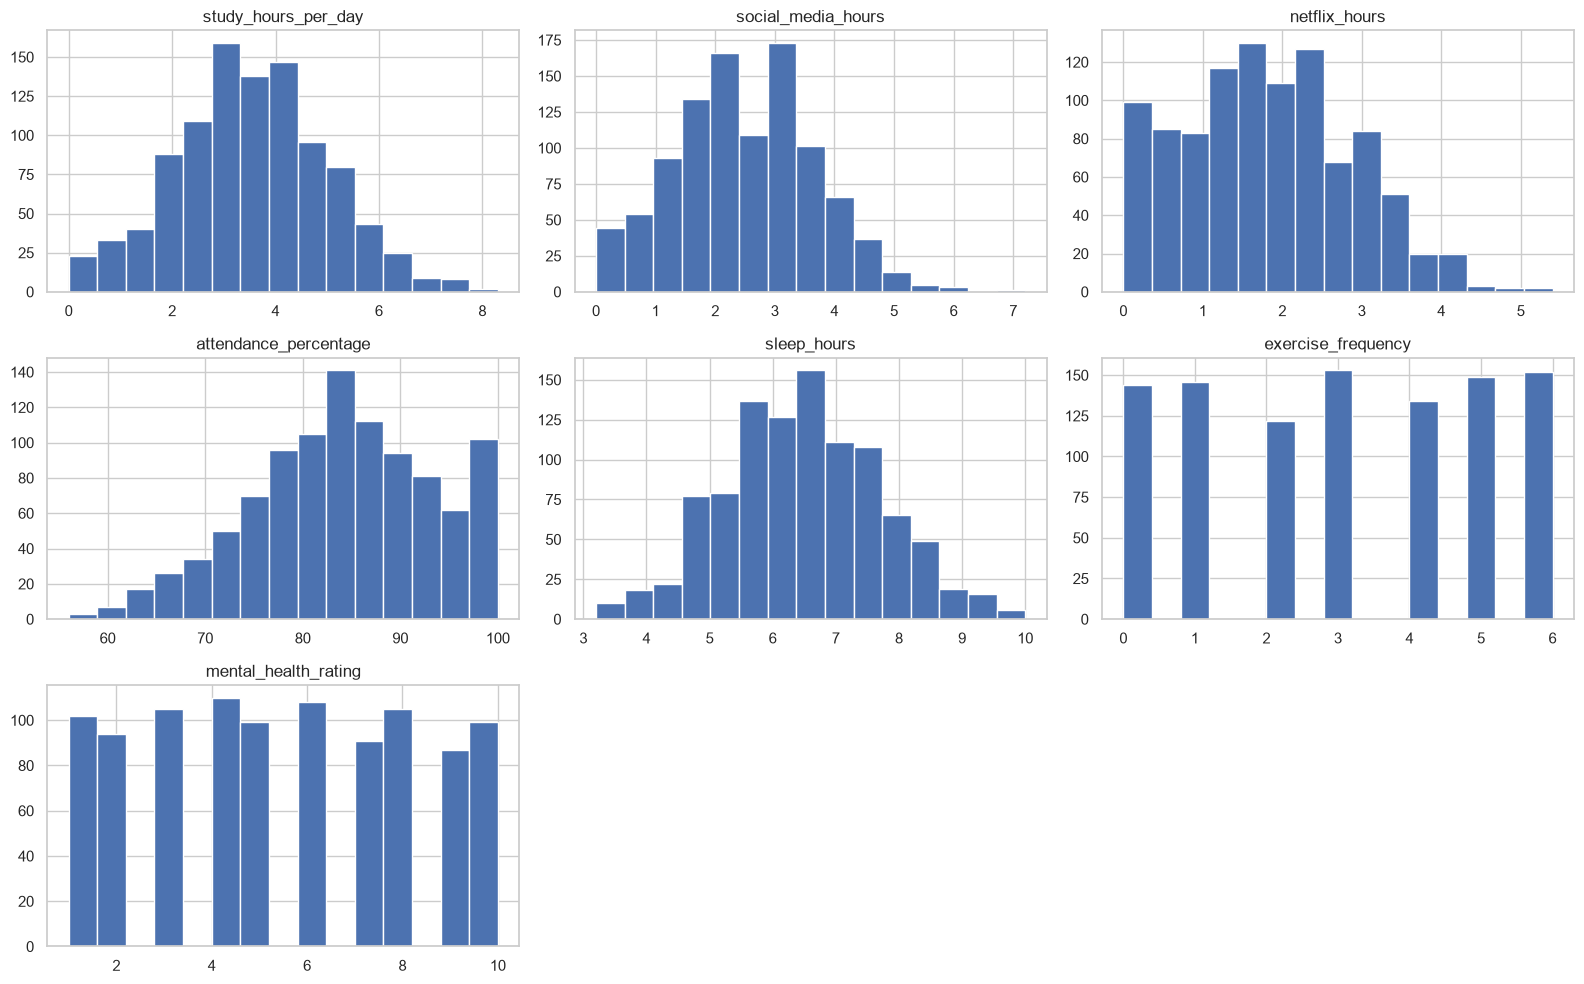

In [15]:
habit_numeric_cols = [
    "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exercise_frequency", "mental_health_rating"
]

df[habit_numeric_cols].hist(figsize=(16, 10), bins=15)
plt.tight_layout()
plt.show()

Histogram menunjukkan `study_hours_per_day`, `social_media_hours`, `netflix_hours`, dan `sleep_hours` mendekati distribusi normal, sementara `attendance_percentage` sedikit menceng ke kiri (banyak mahasiswa dengan kehadiran tinggi, mendekati 100%). `exercise_frequency` dan `mental_health_rating` cenderung tersebar cukup merata di seluruh rentang nilainya (0-6 dan 0-10), menandakan variasi kebiasaan yang cukup besar antar mahasiswa, kondisi yang baik untuk membentuk cluster yang berbeda-beda.

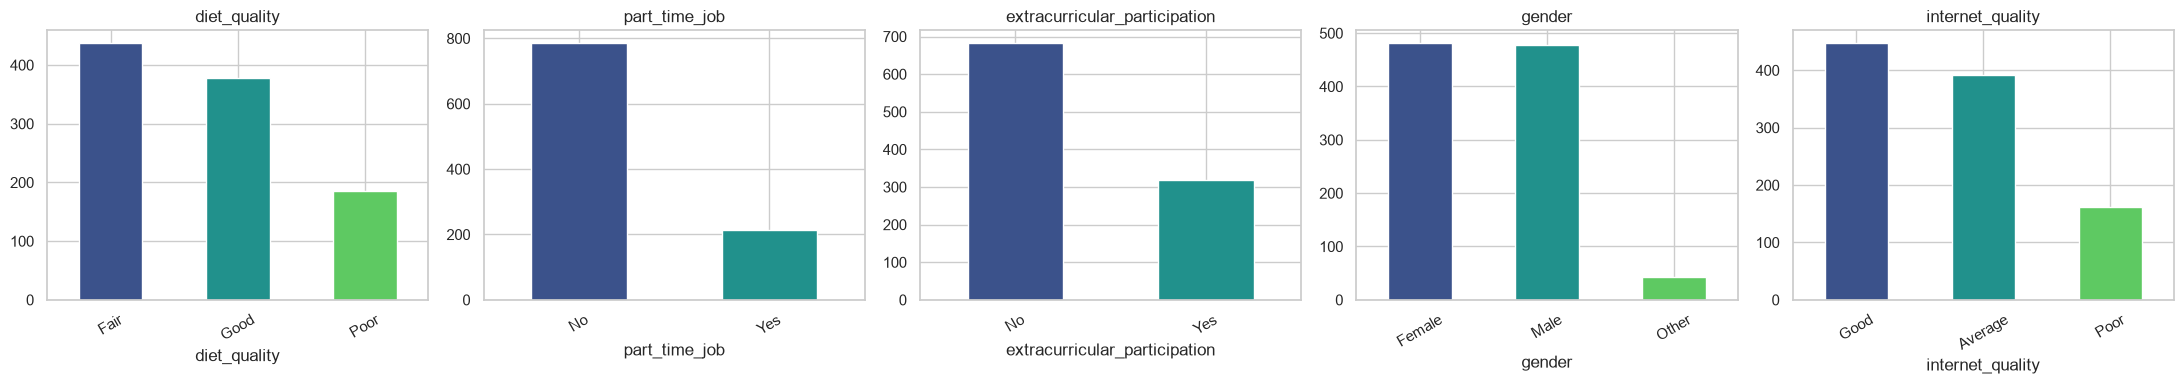

In [16]:
cat_cols = ["diet_quality", "part_time_job", "extracurricular_participation", "gender", "internet_quality"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind="bar", ax=ax, color=sns.color_palette("viridis", 3))
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Distribusi kategorikal menunjukkan mayoritas mahasiswa tidak memiliki pekerjaan paruh waktu (`part_time_job` = No) dan cukup aktif berorganisasi (`extracurricular_participation` didominasi Yes/No berimbang). `diet_quality` didominasi kategori Fair dan Good. `gender` dan `internet_quality` ditampilkan untuk konteks demografis/infrastruktur, namun keduanya tidak dipakai sebagai fitur clustering (lihat bagian 6).

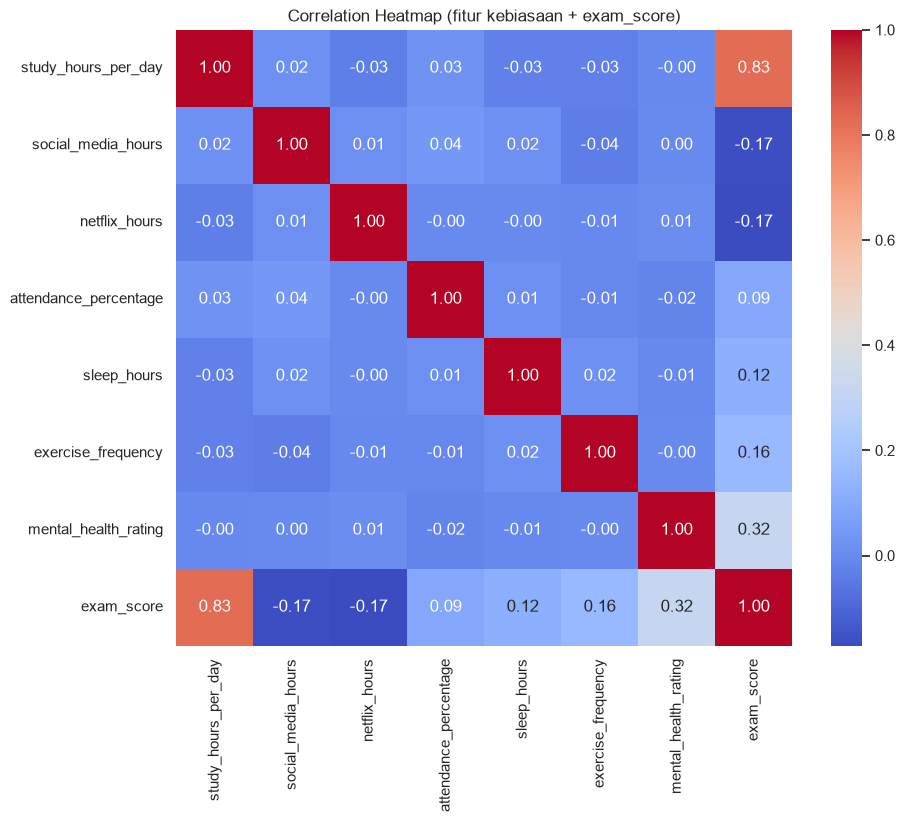

In [17]:
numeric_cols_for_corr = habit_numeric_cols + ["exam_score"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols_for_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (fitur kebiasaan + exam_score)")
plt.show()

`exam_score` sengaja disertakan di heatmap ini (walau tidak dipakai untuk clustering) untuk melihat sekilas hubungan antar kebiasaan dan hasil akademik. Terlihat `study_hours_per_day` berkorelasi positif paling kuat dengan `exam_score`, sedangkan `social_media_hours` dan `netflix_hours` berkorelasi negatif. Ini konsisten dengan intuisi bahwa waktu belajar yang lebih banyak dan screen time yang lebih sedikit berasosiasi dengan nilai ujian lebih baik. Korelasi antar fitur kebiasaan sendiri relatif rendah (tidak ada multikolinearitas kuat), sehingga seluruh fitur kebiasaan layak dipertahankan untuk clustering.

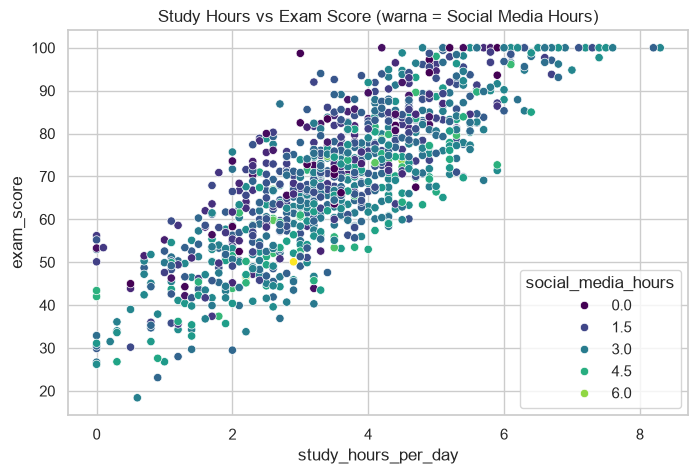

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours_per_day", y="exam_score", hue="social_media_hours", palette="viridis")
plt.title("Study Hours vs Exam Score (warna = Social Media Hours)")
plt.show()

Scatter plot ini murni eksploratif (bukan bagian dari clustering) untuk insight awal: mahasiswa dengan jam belajar tinggi DAN jam media sosial rendah (warna gelap) cenderung berada di titik `exam_score` tertinggi. Ini menguatkan dugaan bahwa kombinasi kebiasaan (bukan cuma satu faktor) yang menentukan performa akademik, relevan untuk nanti dibandingkan dengan rata-rata `exam_score` per cluster pada bagian training (dikerjakan Rafi).

## 5. Ringkasan Insight EDA

- Dataset bersih dari duplikat; missing value hanya ada di kolom demografis yang tidak dipakai untuk clustering.
- Fitur kebiasaan numerik memiliki variasi yang cukup besar antar mahasiswa dan korelasi antar-fitur yang rendah, kondisi yang cocok untuk clustering (fitur tidak saling redundan).
- `study_hours_per_day` dan screen time (`social_media_hours`, `netflix_hours`) tampak paling berasosiasi dengan `exam_score`, sehingga kombinasi ini kemungkinan akan menjadi pembeda utama antar cluster nantinya.

## 6. Pemilihan Fitur untuk Clustering

Sesuai brief, `exam_score` (dan academic performance secara umum) **tidak** digunakan sebagai fitur clustering, supaya pengelompokan murni berdasarkan kebiasaan, dan performa akademik justru dipakai sebagai pembanding hasil cluster setelah clustering terbentuk (dikerjakan di bagian training).

Fitur yang dipilih untuk clustering adalah **kebiasaan/perilaku murni** mahasiswa:
- `study_hours_per_day`, `social_media_hours`, `netflix_hours`, `attendance_percentage`, `sleep_hours`, `exercise_frequency`, `mental_health_rating` (numerik)
- `diet_quality` (ordinal: Poor/Fair/Good)
- `part_time_job`, `extracurricular_participation` (biner: No/Yes)

Kolom berikut **di-exclude** dari fitur clustering karena bersifat demografis atau infrastruktur, bukan kebiasaan:
- `student_id` (identifier, bukan fitur)
- `age`, `gender`, `parental_education_level` (demografi/latar belakang, bukan kebiasaan yang bisa diintervensi)
- `internet_quality` (infrastruktur/akses, bukan pilihan kebiasaan mahasiswa)
- `exam_score` (hasil akademik, sesuai brief untuk menjaga clustering murni unsupervised berdasarkan kebiasaan)

## 7. Preprocessing

In [19]:
df_features = df.copy()

diet_map = {"Poor": 0, "Fair": 1, "Good": 2}

df_features["diet_quality_encoded"] = df_features["diet_quality"].map(diet_map)
df_features["part_time_job_encoded"] = df_features["part_time_job"].map(binary_map)
df_features["extracurricular_participation_encoded"] = df_features["extracurricular_participation"].map(binary_map)

clustering_features = habit_numeric_cols + [
    "diet_quality_encoded", "part_time_job_encoded", "extracurricular_participation_encoded"
]

X = df_features[clustering_features]
print("Jumlah fitur clustering:", X.shape[1])
print("Missing value pada feature matrix:", X.isnull().sum().sum())
X.head()

Jumlah fitur clustering: 10
Missing value pada feature matrix: 0


,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,diet_quality_encoded,part_time_job_encoded,extracurricular_participation_encoded
0,0.0,1.2,1.1,85.0,8.0,6,8,1,0,1
1,6.9,2.8,2.3,97.3,4.6,6,8,2,0,0
2,1.4,3.1,1.3,94.8,8.0,1,1,0,0,0
3,1.0,3.9,1.0,71.0,9.2,4,1,0,0,1
4,5.0,4.4,0.5,90.9,4.9,3,1,1,0,0


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)
print("Shape feature matrix ter-scaling:", X_scaled_df.shape)
X_scaled_df.describe().T[["mean", "std"]]

Shape feature matrix ter-scaling: (1000, 10)


,mean,std
study_hours_per_day,-3.304024e-16,1.0005
social_media_hours,-4.973799e-17,1.0005
netflix_hours,-9.947598e-17,1.0005
attendance_percentage,5.293543e-16,1.0005
sleep_hours,-3.446132e-16,1.0005
exercise_frequency,4.796163e-17,1.0005
mental_health_rating,1.030287e-16,1.0005
diet_quality_encoded,-1.136868e-16,1.0005
part_time_job_encoded,-3.907985e-17,1.0005
extracurricular_participation_encoded,-3.552714e-17,1.0005


Encoding: `diet_quality` di-encode ordinal (Poor=0, Fair=1, Good=2) karena punya urutan tingkatan yang jelas; `part_time_job` dan `extracurricular_participation` di-encode biner (No=0, Yes=1). Semua fitur clustering ini numerik dan bebas dari missing value (0 missing di feature matrix), sehingga sudah bisa langsung di-scaling. Hasil `StandardScaler` menunjukkan setiap fitur punya mean ~0 dan std ~1, siap dipakai untuk clustering.

## 8. Training.

Feature matrix `X_scaled` sudah siap dipakai oleh notebook training. Selanjutnya, analisis difokuskan pada pemilihan `k` terbaik, evaluasi kualitas cluster, visualisasi 2D dengan PCA, dan interpretasi pola kebiasaan yang paling membedakan antarcluster.

In [21]:
# Feature matrix final untuk training K-Means
# X_scaled dipertahankan sebagai array 1000 x 10 fitur kebiasaan yang sudah di-standardize
X_scaled = X_scaled_df.to_numpy()

print("Shape X_scaled:", X_scaled.shape)
print("Jumlah fitur:", X_scaled.shape[1])


Shape X_scaled: (1000, 10)
Jumlah fitur: 10


Hasil pengelompokan menunjukkan bahwa struktur cluster di data ini cenderung halus, bukan terpisah tajam. Dengan `k=2`, Silhouette Score berada di angka `0.1444`, yang berarti pemisahan cluster ada tetapi masih saling overlap. Ini wajar untuk data kebiasaan mahasiswa yang variasinya lebih kontinu daripada diskret.

Secara ringkas, cluster yang terbentuk dapat dibaca sebagai dua pola kebiasaan utama:
- **Cluster 0**: cenderung memiliki jam belajar sedikit lebih rendah, penggunaan media sosial relatif lebih tinggi, attendance lebih rendah, dan proporsi part-time job lebih besar.
- **Cluster 1**: sedikit lebih kuat pada jam belajar dan attendance, part-time job lebih rendah, serta rata-rata `exam_score` sedikit lebih tinggi.

Bonus insight: perbedaan rata-rata `exam_score` antar cluster memang tidak besar, tetapi cluster dengan kebiasaan belajar dan kehadiran yang lebih baik tetap menunjukkan performa akademik yang sedikit lebih tinggi. Ini mendukung interpretasi bahwa pola kebiasaan harian memberi sinyal, meski bukan satu-satunya faktor yang menentukan nilai ujian.

## 9. Training K-Means dan Pemilihan Jumlah Cluster

Bagian ini mencari jumlah cluster yang paling masuk akal dengan **Elbow Method**, lalu memvalidasinya menggunakan **Silhouette Score**. Setelah `k` terpilih, model K-Means dilatih pada feature matrix yang sudah di-scaling.

Sebelum masuk ke kode, alur training dibagi jadi tiga tahap. Pertama, menyiapkan library yang dibutuhkan untuk K-Means, PCA, dan silhouette. Kedua, mencoba beberapa nilai `k` untuk melihat titik elbow sekaligus skor silhouette terbaik. Ketiga, melatih model final, memvisualisasikan hasil cluster, lalu membaca karakter tiap cluster dan membandingkan `exam_score`.

In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("K-Means, PCA, dan silhouette siap dipakai.")

K-Means, PCA, dan silhouette siap dipakai.


Sel pertama hanya menyiapkan komponen analisis. `KMeans` dipakai untuk membentuk cluster, `PCA` untuk menurunkan dimensi ke 2D agar bisa divisualisasikan, dan `silhouette_score` untuk mengevaluasi seberapa baik pemisahan cluster yang dihasilkan.

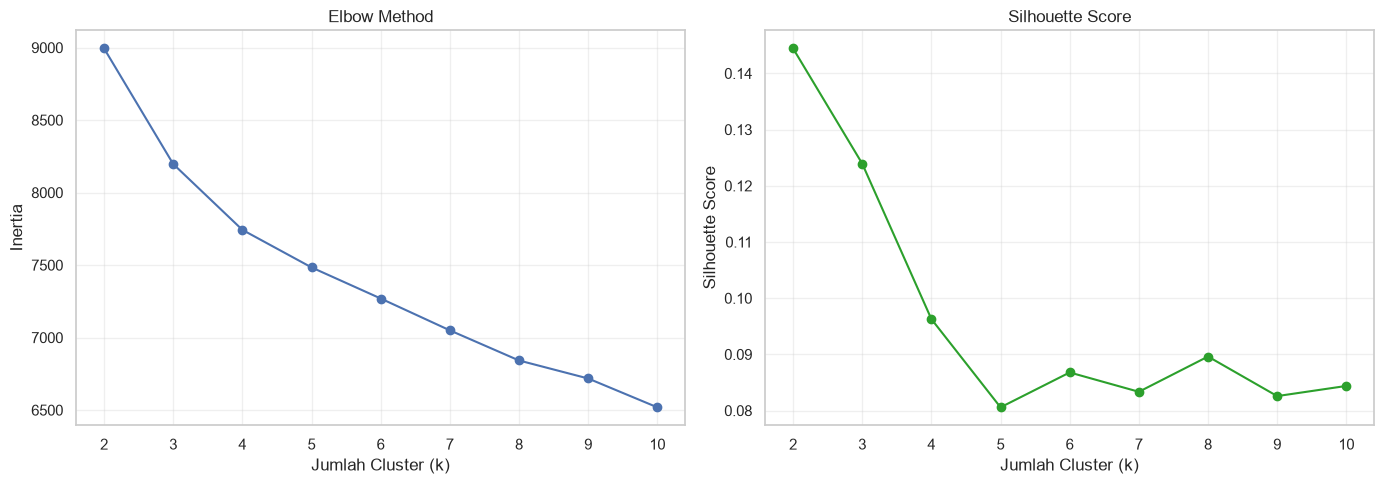

 k   inertia  silhouette_score
 2 8994.4498            0.1444
 3 8197.0770            0.1239
 4 7743.0301            0.0963
 5 7484.0086            0.0806
 6 7269.5590            0.0868
 7 7049.8360            0.0833
 8 6842.1145            0.0896
 9 6717.8035            0.0826
10 6518.9869            0.0844


In [23]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

metrics_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(metrics_df["k"], metrics_df["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df["k"], metrics_df["silhouette_score"], marker="o", color="tab:green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(metrics_df.round(4).to_string(index=False))

Di tahap ini, beberapa nilai `k` diuji dari 2 sampai 10. Untuk setiap `k`, model K-Means dihitung inertia-nya untuk Elbow Method dan juga silhouette score-nya untuk melihat kualitas pemisahan cluster. Grafik yang muncul membantu memilih `k` yang seimbang antara kompaksi cluster dan pemisahan antarcluster.

k terpilih: 2
Silhouette Score final: 0.1444


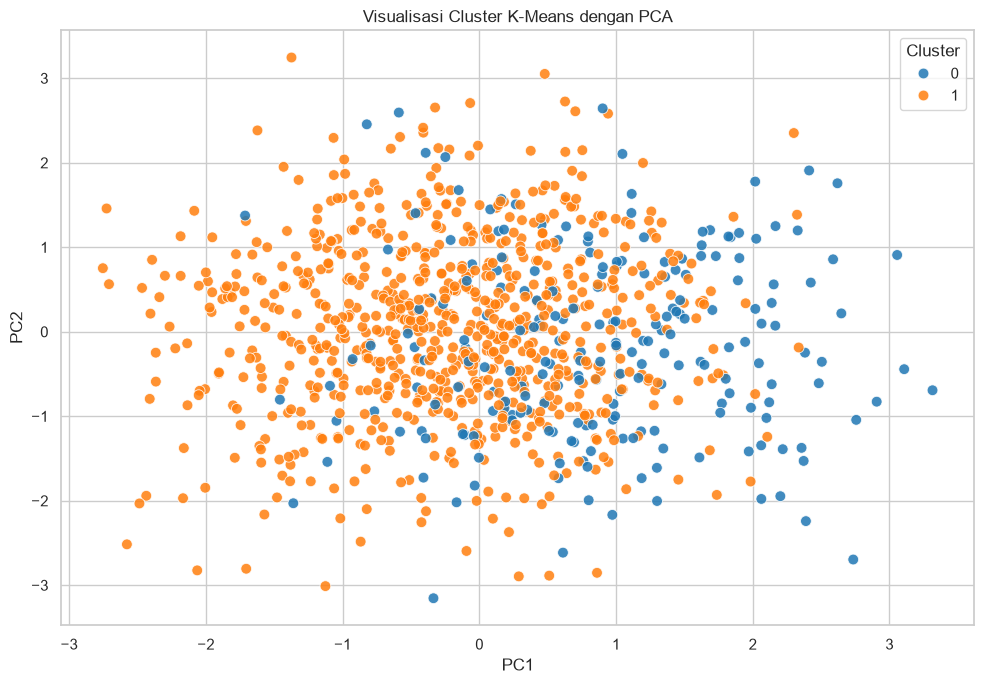

Rata-rata fitur per cluster:
         study_hours_per_day  social_media_hours  netflix_hours  attendance_percentage  sleep_hours  exercise_frequency  mental_health_rating  diet_quality_encoded  part_time_job_encoded  extracurricular_participation_encoded  exam_score
cluster                                                                                                                                                                                                                                      
0                       3.47                2.55           1.84                  83.38         6.47                2.96                  5.51                  1.24                    1.0                                   0.30       68.74
1                       3.57                2.49           1.81                  84.34         6.47                3.06                  5.42                  1.18                    0.0                                   0.32       69.84

Deviasi mean clust

In [24]:
k_selected = metrics_df.loc[metrics_df["silhouette_score"].idxmax(), "k"]

kmeans = KMeans(n_clusters=int(k_selected), random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

clustered_df = df_features.copy()
clustered_df["cluster"] = cluster_labels

silhouette_final = silhouette_score(X_scaled, cluster_labels)
print(f"k terpilih: {k_selected}")
print(f"Silhouette Score final: {silhouette_final:.4f}")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=60, alpha=0.85)
plt.title("Visualisasi Cluster K-Means dengan PCA")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

cluster_profile = clustered_df.groupby("cluster")[clustering_features + ["exam_score"]].mean().round(2)
print("Rata-rata fitur per cluster:")
print(cluster_profile.to_string())

overall_means = clustered_df[clustering_features + ["exam_score"]].mean()
relative_profile = (clustered_df.groupby("cluster")[clustering_features].mean() - overall_means[clustering_features]).round(2)
print("\nDeviasi mean cluster dari rata-rata keseluruhan:")
print(relative_profile.to_string())

print("\nRata-rata exam_score per cluster:")
print(clustered_df.groupby("cluster")["exam_score"].mean().round(2).to_string())

Setelah `k` terbaik ditemukan, model final dilatih ulang menggunakan seluruh feature matrix yang sudah di-scaling. Hasil label cluster lalu digabung kembali ke dataframe asli supaya profil tiap cluster bisa dihitung. PCA dipakai untuk memproyeksikan 10 fitur ke 2 dimensi, sehingga hasil cluster lebih mudah dibaca lewat scatter plot. Bagian akhir merangkum rata-rata fitur per cluster, deviasi terhadap rata-rata keseluruhan, dan rata-rata `exam_score` sebagai insight tambahan.